In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LogNorm
from matplotlib.ticker import AutoMinorLocator
from scipy.optimize import curve_fit
import os, sys

CAFPYANA_WD  = "/home/castalyf/cafpyana"
ANALYSIS_DIR = "."
PLOT_DIR     = "./shower_plots"
DF_OUT_DIR   = "./nuecc_dfs"
TITLE        = r"SBND $\nu_e$ CC Inclusive"

os.makedirs(PLOT_DIR, exist_ok=True)
for p in [CAFPYANA_WD, CAFPYANA_WD + "/pyanalib", ANALYSIS_DIR]:
    if p not in sys.path:
        sys.path.insert(0, p)

import nue_helpers as nh
%load_ext autoreload
%autoreload 2
print("imports OK")

imports OK


In [2]:
SEL_TOPO_FILE = os.path.join(DF_OUT_DIR, "selected_nuecc_topo.df")
sel_topo = pd.read_hdf(SEL_TOPO_FILE)
print(f"sel_topo shape : {sel_topo.shape}")
print(f"columns        : {list(sel_topo.columns)}")

# ── Signal + final-state topology mask ───────────────────────────────────────
sig_se = sel_topo["is_sig"] & sel_topo["sel_single_electron"]
print(f"\nSignal events after single-electron topo cut: {sig_se.sum():,}")

# ── KE, cos θ, momentum  (use actual column names from sel_topo) ─────────────
true_ke = sel_topo.loc[sig_se, "true_ke"]
reco_ke = sel_topo.loc[sig_se, "reco_ke"]
true_ct = sel_topo.loc[sig_se, "true_costheta"]   # fixed
reco_ct = sel_topo.loc[sig_se, "reco_costheta"]   # fixed
true_p  = sel_topo.loc[sig_se, "true_p"]          # already saved
reco_p  = sel_topo.loc[sig_se, "reco_p"]          # already saved

print(f"true_ke  : {true_ke.notna().sum():,} valid")
print(f"reco_ke  : {reco_ke.notna().sum():,} valid")
print(f"true_ct  : {true_ct.notna().sum():,} valid")

sel_topo shape : (2943724, 13)
columns        : ['truth_cat', 'is_sig', 'reco_ke', 'reco_costheta', 'reco_p', 'true_ke', 'true_costheta', 'true_p', 'sel_precut', 'sel_valid_flashmatch', 'sel_fiducial', 'sel_single_electron', 'pot_scale']

Signal events after single-electron topo cut: 10,890
true_ke  : 10,890 valid
reco_ke  : 10,890 valid
true_ct  : 10,890 valid


/home/castalyf/cafpyana/analysis_village/nueCC/./nue_helpers.py:574: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


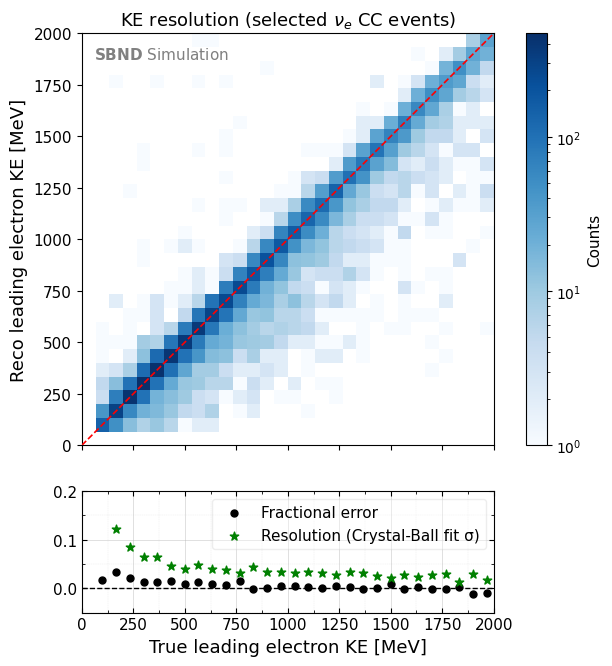

/home/castalyf/cafpyana/analysis_village/nueCC/./nue_helpers.py:1190: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/home/castalyf/cafpyana/analysis_village/nueCC/./nue_helpers.py:574: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


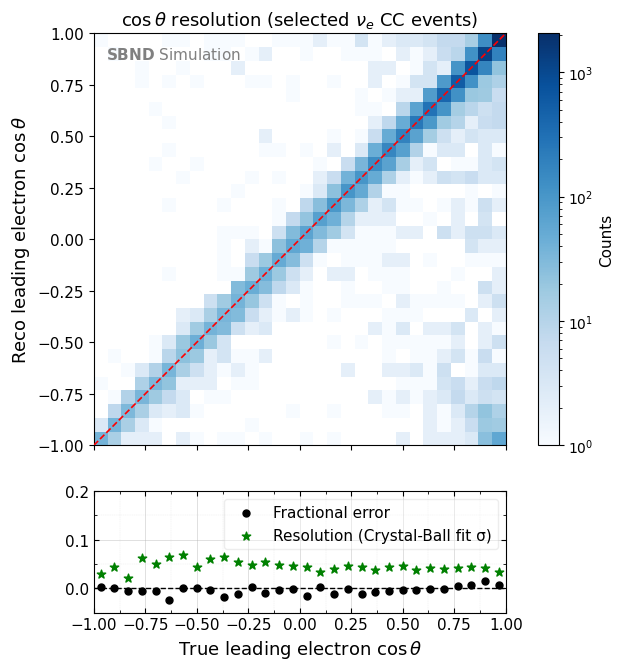

/home/castalyf/cafpyana/analysis_village/nueCC/./nue_helpers.py:1190: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/home/castalyf/cafpyana/analysis_village/nueCC/./nue_helpers.py:574: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


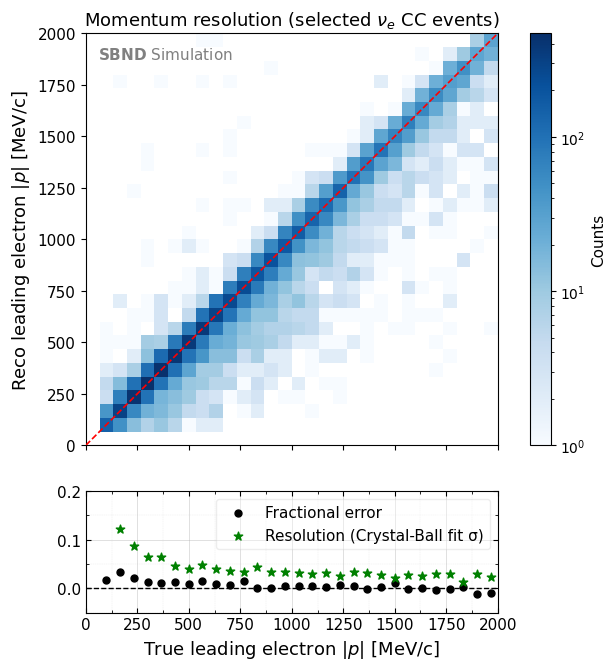

/home/castalyf/cafpyana/analysis_village/nueCC/./nue_helpers.py:1190: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


In [3]:
ke_bins_2d = np.linspace(0,   2000, 31)
ct_bins_2d = np.linspace(-1,    1, 31)
p_bins_2d  = np.linspace(0,  2000, 31)

# KE
fig_ke, _ = nh.plot_leading_e_resolution(
    true_series = true_ke, reco_series = reco_ke,
    bins        = ke_bins_2d, stage_idx = None,
    xlabel      = 'True leading electron KE [MeV]',
    ylabel      = 'Reco leading electron KE [MeV]',
    normalize   = True,  log_color = True,
    title       = fr"KE resolution (selected $\nu_e$ CC events)",
)
plt.show()
nh.save_plot("resolution_ke_topo", fig=fig_ke, folder_name=PLOT_DIR)

# cos θ
fig_ct, _ = nh.plot_leading_e_resolution(
    true_series = true_ct, reco_series = reco_ct,
    bins        = ct_bins_2d, stage_idx = None,
    xlabel      = r'True leading electron $\cos\theta$',
    ylabel      = r'Reco leading electron $\cos\theta$',
    normalize   = False, log_color = True,
    title       = fr"$\cos\theta$ resolution (selected $\nu_e$ CC events)",
)
plt.show()
nh.save_plot("resolution_costheta_topo", fig=fig_ct, folder_name=PLOT_DIR)

# momentum
fig_p, _ = nh.plot_leading_e_resolution(
    true_series = true_p, reco_series = reco_p,
    bins        = p_bins_2d, stage_idx = None,
    xlabel      = r'True leading electron $|p|$ [MeV/c]',
    ylabel      = r'Reco leading electron $|p|$ [MeV/c]',
    normalize   = True,  log_color = True,
    title       = fr"Momentum resolution (selected $\nu_e$ CC events)",
)
plt.show()
nh.save_plot("resolution_p_topo", fig=fig_p, folder_name=PLOT_DIR)

In [4]:
from scipy.optimize import curve_fit
from scipy.stats import norm as sp_norm

# ═══════════════════════════════════════════════════════════════════════════════
# Fit functions  — both take the SAME bins used for display
# ═══════════════════════════════════════════════════════════════════════════════
def _cb(t, A, alpha, n, mu, sigma):
    t   = np.asarray(t, dtype=float)
    out = np.empty_like(t)
    z   = (t - mu) / sigma
    g   = z > -alpha
    out[g]  = np.exp(-0.5 * z[g]**2)
    Ap = (n / alpha)**n * np.exp(-0.5 * alpha**2)
    Bp = n / alpha - alpha
    out[~g] = Ap * (Bp - z[~g])**(-n)
    return A * out


def _gauss(x, A, mu, sigma):
    return A * np.exp(-0.5 * ((x - mu) / sigma)**2)


def _fit_to_hist(stat, display_bins, fit_type='cb'):
    """
    Fit to the SAME histogram that will be displayed.
    Returns (popt, fit_ok, fit_fn, param_names)
    """
    counts, edges = np.histogram(stat, bins=display_bins)
    centers = 0.5 * (edges[:-1] + edges[1:])
    m  = float(np.nanmean(stat))
    s  = max(float(np.nanstd(stat)), 1e-9)
    A0 = max(float(counts.max()), 1.0)

    if fit_type == 'gauss':
        p0 = [A0,       m,        s      ]
        lo = [0,        m - 3*s,  1e-9   ]
        hi = [20*A0+1,  m + 3*s,  5*s    ]
        fn = _gauss
        names = ['A', 'mu', 'sigma']
    else:  # 'cb'
        p0 = [A0,       1.5,  2.0,   m,        s      ]
        lo = [0,        0.1,  1.01,  m - 3*s,  1e-9   ]
        hi = [20*A0+1,  5.,   50.,   m + 3*s,  5*s    ]
        fn = _cb
        names = ['A', 'alpha', 'n', 'mu', 'sigma']

    try:
        popt, _ = curve_fit(fn, centers, counts,
                            p0=p0, bounds=(lo, hi), maxfev=10000)
        return popt, True, fn, names
    except Exception:
        return p0, False, fn, names


In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
# Per-bin panel plot  —  fit_type='cb' or 'gauss'
# ═══════════════════════════════════════════════════════════════════════════════
def plot_per_bin_panels(true_series, reco_series,
                        bins, bin_labels,
                        normalize    = True,
                        suptitle     = '',
                        bin_var_label= '',
                        unit         = '',
                        res_range    = (-1.0, 1.0),
                        n_cols       = 4,
                        n_fit_bins   = 60,
                        fit_type     = 'cb'):       # <── 'cb' or 'gauss'

    bins_arr = np.asarray(bins, dtype=float)
    n_bins   = len(bins_arr) - 1
    n_rows   = int(np.ceil(n_bins / n_cols))

    fig_w  = 5.0 * n_cols
    fig_h  = 4.0 * n_rows
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_w, fig_h))
    axes = np.array(axes).flatten()

    valid = true_series.notna() & reco_series.notna()
    xa    = true_series[valid].astype(float)
    ya    = reco_series[valid].astype(float)

    res_label  = (r'$(reco - true)\,/\,true$' if normalize else r'$reco - true$')
    fit_color  = 'salmon'   if fit_type == 'cb' else 'limegreen'
    fit_label  = 'Crystal Ball fit' if fit_type == 'cb' else 'Gaussian fit'

    # shared display bins — fit uses THESE exact bins
    display_bins = np.linspace(res_range[0], res_range[1], n_fit_bins + 1)

    for i in range(n_bins):
        ax     = axes[i]
        lo, hi = bins_arr[i], bins_arr[i + 1]
        label  = bin_labels[i] if bin_labels else (
            f'{lo:.2g}–{hi:.2g}' if hi != np.inf else f'>{lo:.2g}')

        in_bin = (xa > lo) & (xa <= hi)
        xb, yb = xa[in_bin], ya[in_bin]
        if normalize:
            keep   = np.abs(xb) > 1e-6
            xb, yb = xb[keep], yb[keep]
            stat   = ((yb - xb) / xb).dropna()
        else:
            stat = (yb - xb).dropna()

        n_entries = len(stat)
        raw_mean  = float(np.nanmean(stat)) if n_entries > 0 else np.nan
        raw_std   = float(np.nanstd(stat))  if n_entries > 0 else np.nan

        # ── fit (same bins as display) ────────────────────────────────────
        if n_entries >= 15:
            popt, fit_ok, fit_fn, pnames = _fit_to_hist(
                stat.values, display_bins, fit_type=fit_type)
            mu_fit    = popt[pnames.index('mu')]
            sigma_fit = popt[pnames.index('sigma')]
        else:
            fit_ok = False
            mu_fit = sigma_fit = np.nan

        # ── histogram ─────────────────────────────────────────────────────
        ax.hist(stat, bins=display_bins,
                color='steelblue', edgecolor='white', linewidth=0.3,
                label=f'{n_entries:,} Entries', zorder=2)

        # ── fit overlay (dense x so curve is smooth) ──────────────────────
        if fit_ok:
            t_fine = np.linspace(res_range[0], res_range[1], 600)
            ax.plot(t_fine, fit_fn(t_fine, *popt),
                    color=fit_color, lw=2.0, label=fit_label, zorder=3)

        # ── panel title ───────────────────────────────────────────────────
        unit_str = f' {unit}' if unit else ''
        ax.set_title(fr'{bin_var_label} {label}{unit_str}',
                     fontsize=9.5, pad=3)

        # ── annotation ────────────────────────────────────────────────────
        if fit_ok:
            txt = (f'Fit:\n'
                   f'  σ = {sigma_fit:.3f}\n'
                   f'  μ = {mu_fit:+.3f}\n\n'
                   f'Raw:\n'
                   f'  std  = {raw_std:.3f}\n'
                   f'  mean = {raw_mean:+.3f}')
        else:
            txt = (f'Raw:\n'
                   f'  std  = {raw_std:.3f}\n'
                   f'  mean = {raw_mean:+.3f}\n'
                   f'  (fit failed)')

        ax.text(0.03, 0.97, txt,
                transform=ax.transAxes, va='top', ha='left',
                fontsize=8, family='monospace')

        ax.legend(fontsize=7.5, loc='upper right')
        ax.set_xlabel(res_label, fontsize=8.5)
        ax.set_ylabel('Entries',  fontsize=8.5)
        ax.set_xlim(res_range)
        ax.axvline(0, ls='--', color='black', lw=0.8, alpha=0.5)
        ax.tick_params(labelsize=7.5)

    for j in range(n_bins, len(axes)):
        axes[j].set_visible(False)

    if suptitle:
        fig.suptitle(suptitle, fontsize=11, y=1.0)

    fig.tight_layout(rect=[0, 0, 1, 0.98 if suptitle else 1.0],
                     h_pad=3.0, w_pad=1.5)
    return fig, axes




In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
# Binning
# ═══════════════════════════════════════════════════════════════════════════════
ke_bins_1d = np.array([0, 200, 400, 600, 800, 1000, 1500, 2000, np.inf])
ke_labels  = ["[0, 200]", "[200, 400]", "[400, 600]", "[600, 800]",
              "[800, 1000]", "[1000, 1500]", "[1500, 2000]", ">2000"]

ct_bins_1d = np.array([-1.0, -0.75, -0.5, -0.25, 0.0, 0.25, 0.5, 0.75, 1.0])
ct_labels  = [f"[{a:.2f}, {b:.2f}]"
              for a, b in zip(ct_bins_1d[:-1], ct_bins_1d[1:])]

p_bins_1d = np.array([0, 200, 400, 600, 800, 1000, 1500, 2000, np.inf])
p_labels  = ["[0, 200]", "[200, 400]", "[400, 600]", "[600, 800]",
              "[800, 1000]", "[1000, 1500]", "[1500, 2000]", ">2000"]


# ═══════════════════════════════════════════════════════════════════════════════
# Produce both CB and Gaussian versions for all three variables
# ═══════════════════════════════════════════════════════════════════════════════
_vars = [
    dict(true=true_ke, reco=reco_ke, bins=ke_bins_1d, labels=ke_labels,
         normalize=True,  var_label=r'$KE_{True}$ in', unit='MeV',
         res_range=(-1.0, 1.0), tag='ke',       name='KE'),
    dict(true=true_ct, reco=reco_ct, bins=ct_bins_1d, labels=ct_labels,
         normalize=False, var_label=r'$\cos\theta_{True}$ in', unit='',
         res_range=(-0.4, 0.4), tag='costheta', name=r'$\cos\theta$'),
    dict(true=true_p,  reco=reco_p,  bins=p_bins_1d,  labels=p_labels,
         normalize=True,  var_label=r'$p_{True}$ in', unit='MeV/c',
         res_range=(-1.0, 1.0), tag='p',        name=r'$|p|$'),
]

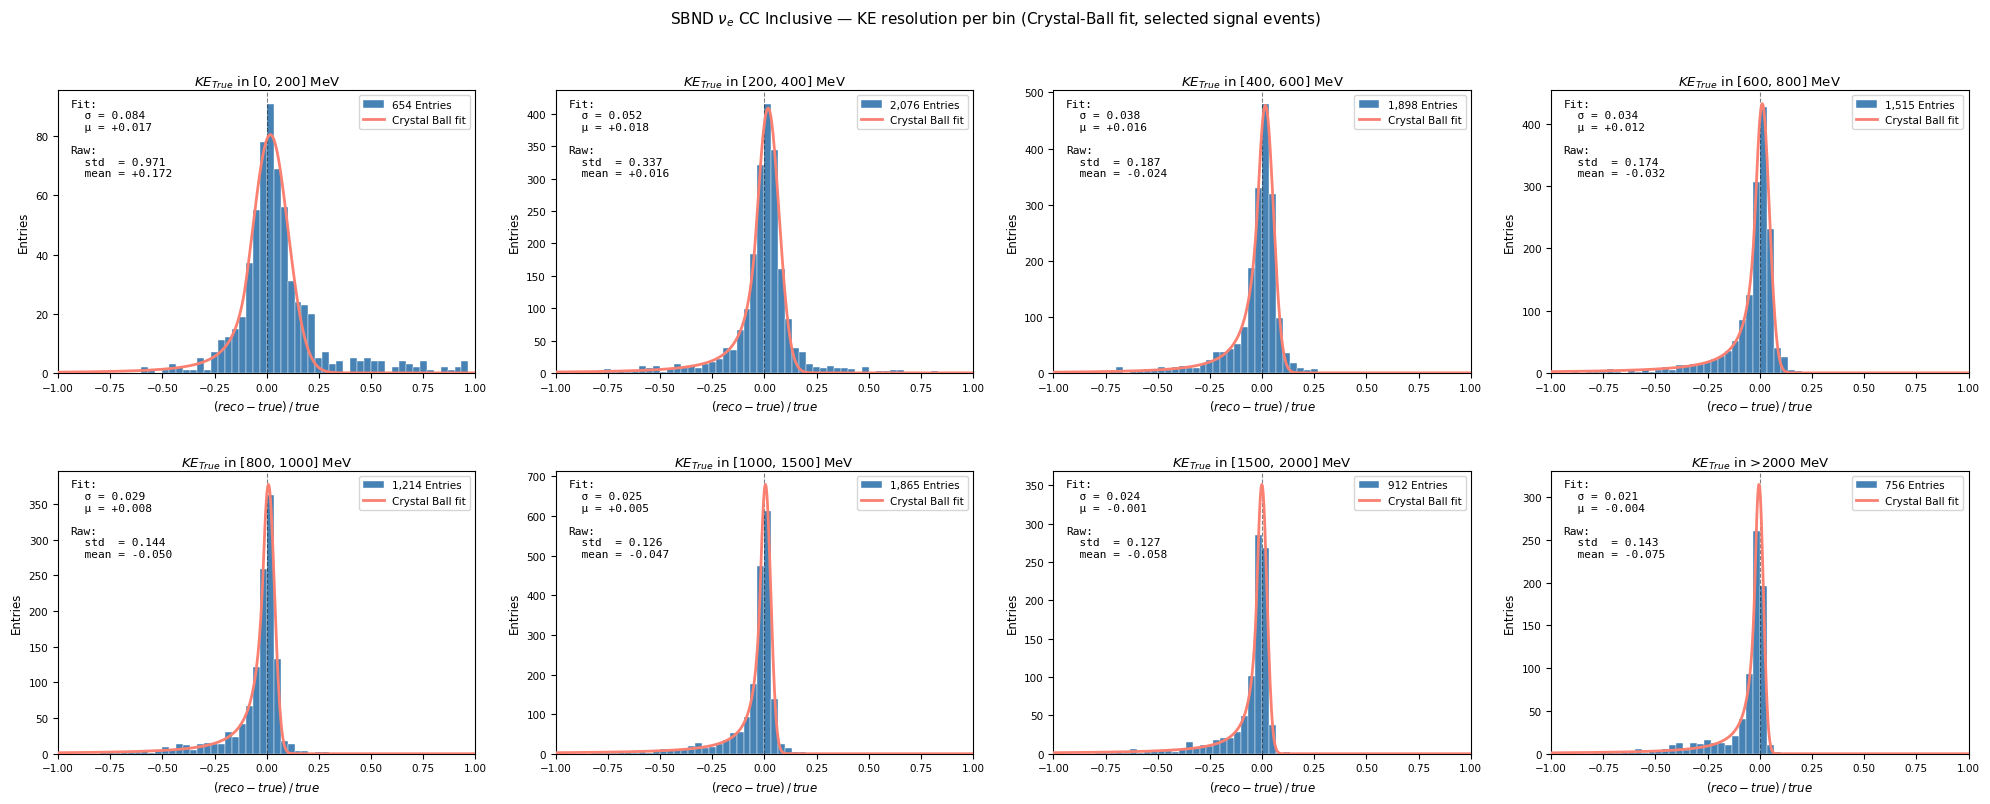

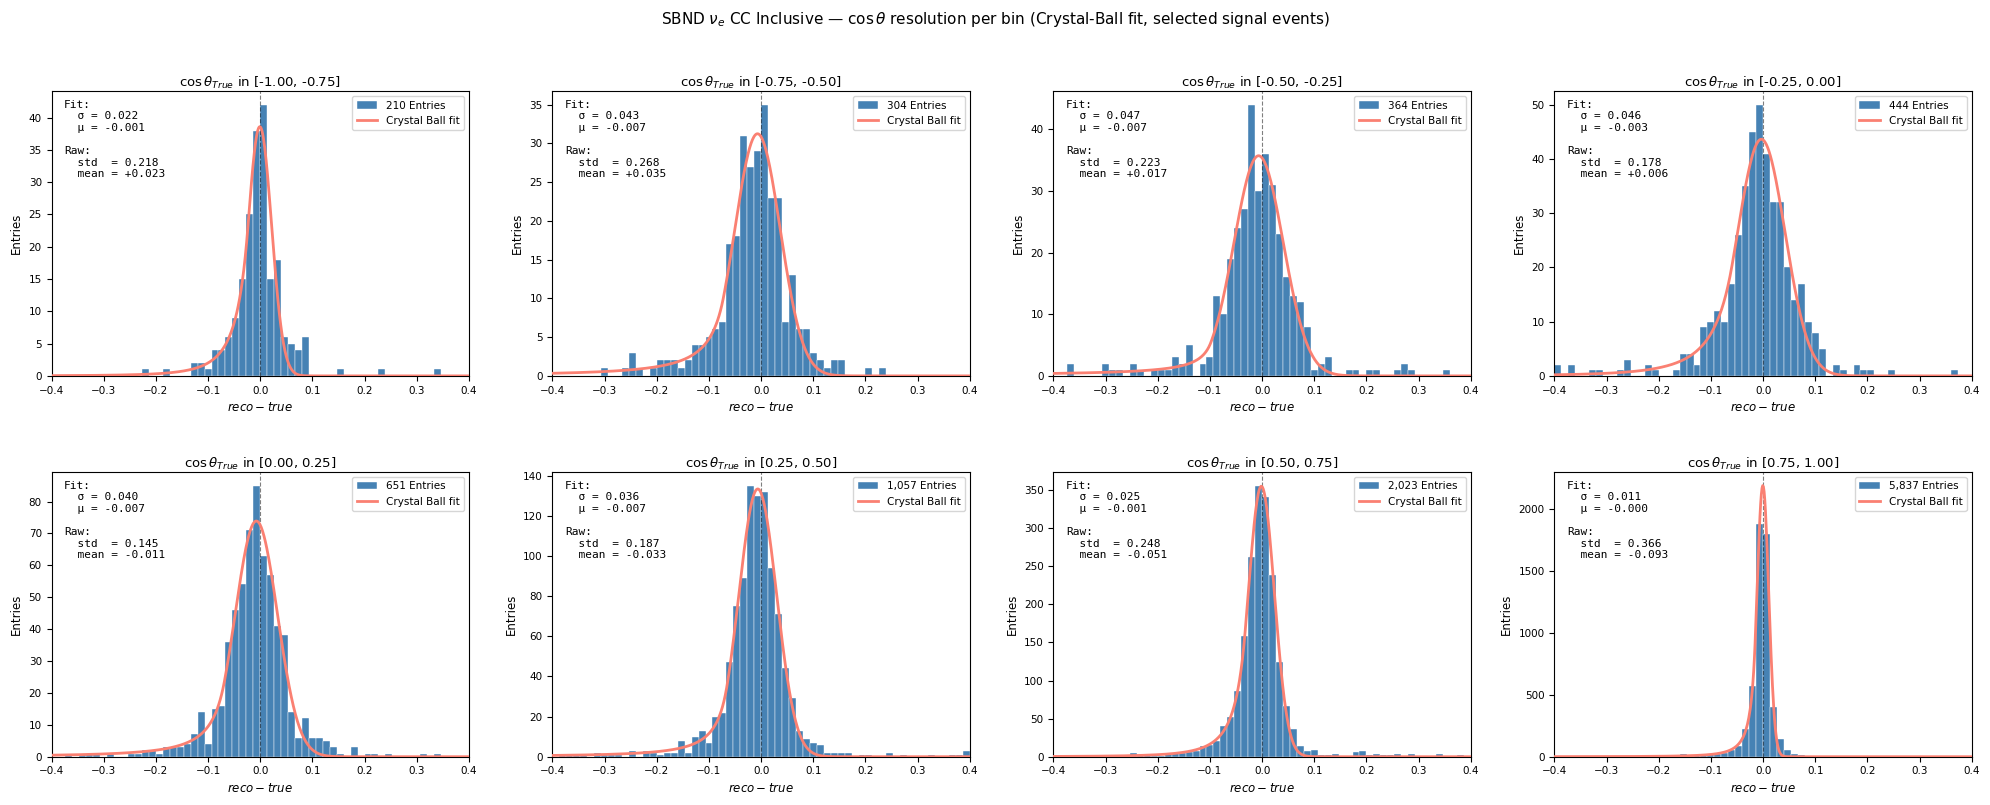

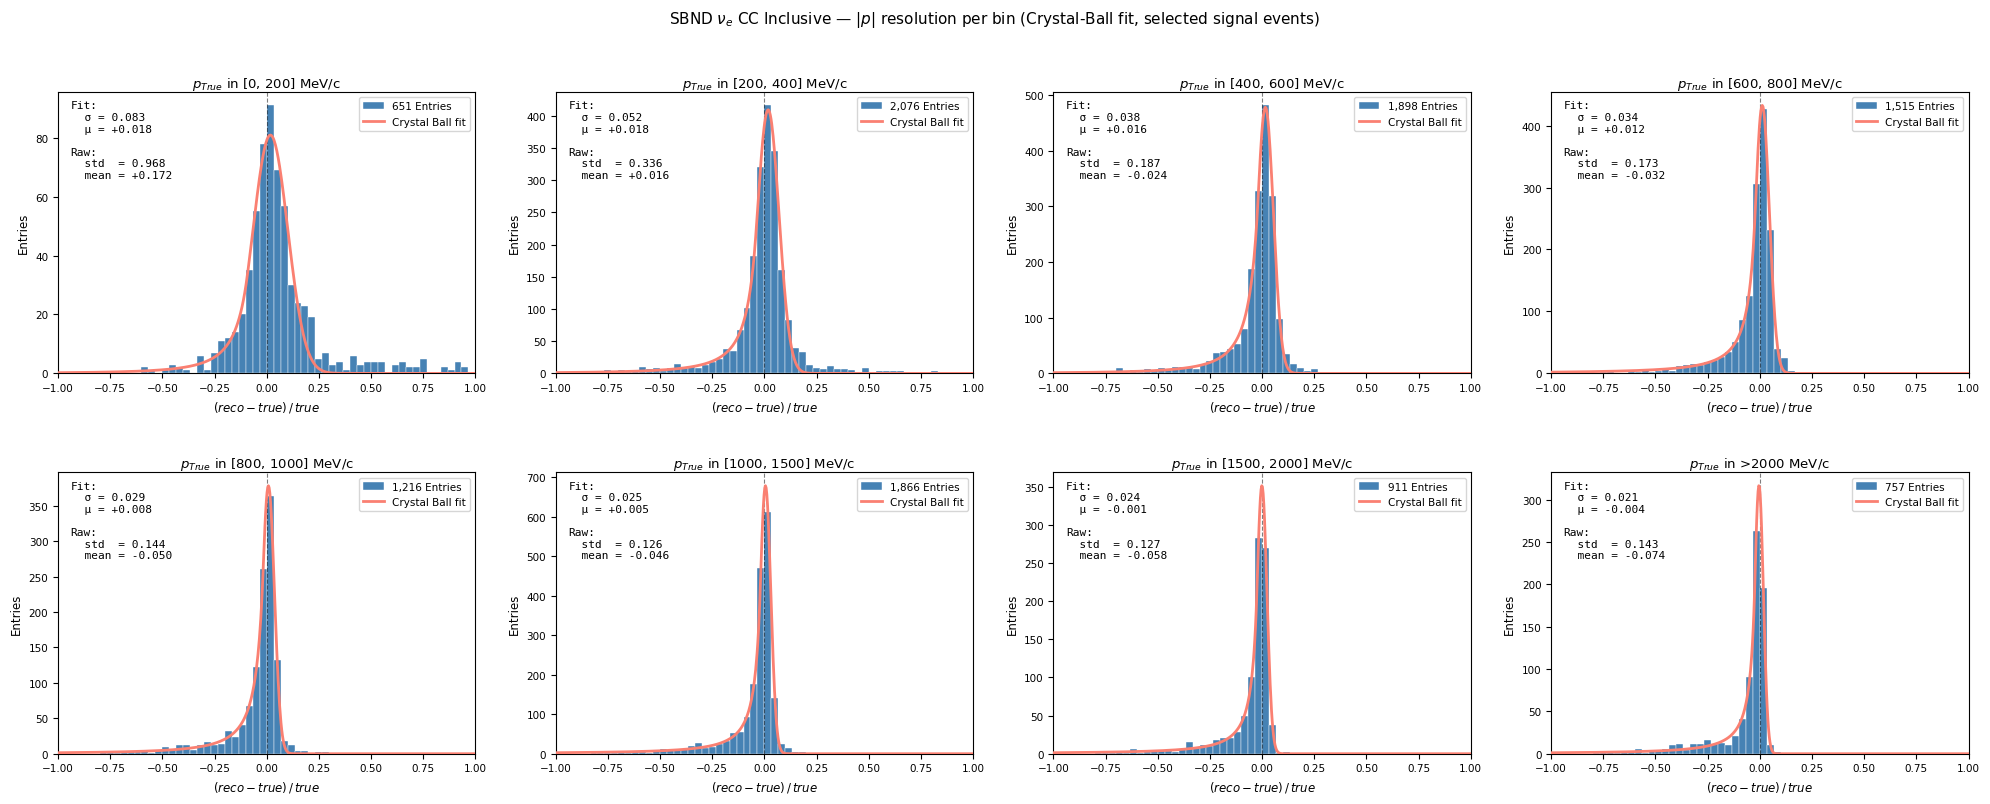

In [8]:
for v in _vars:
    fig, _ = plot_per_bin_panels(
        v['true'], v['reco'],
        bins          = v['bins'],
        bin_labels    = v['labels'],
        normalize     = v['normalize'],
        suptitle      = (fr"{TITLE} — {v['name']} resolution per bin"
                         fr" (Crystal-Ball fit, selected signal events)"),
        bin_var_label = v['var_label'],
        unit          = v['unit'],
        res_range     = v['res_range'],
        n_cols        = 4,
        fit_type      = 'cb',
    )
    plt.show()
    nh.save_plot(
        f"resolution_{v['tag']}_perbin_cb",
        fig=fig,
        folder_name=PLOT_DIR
    )

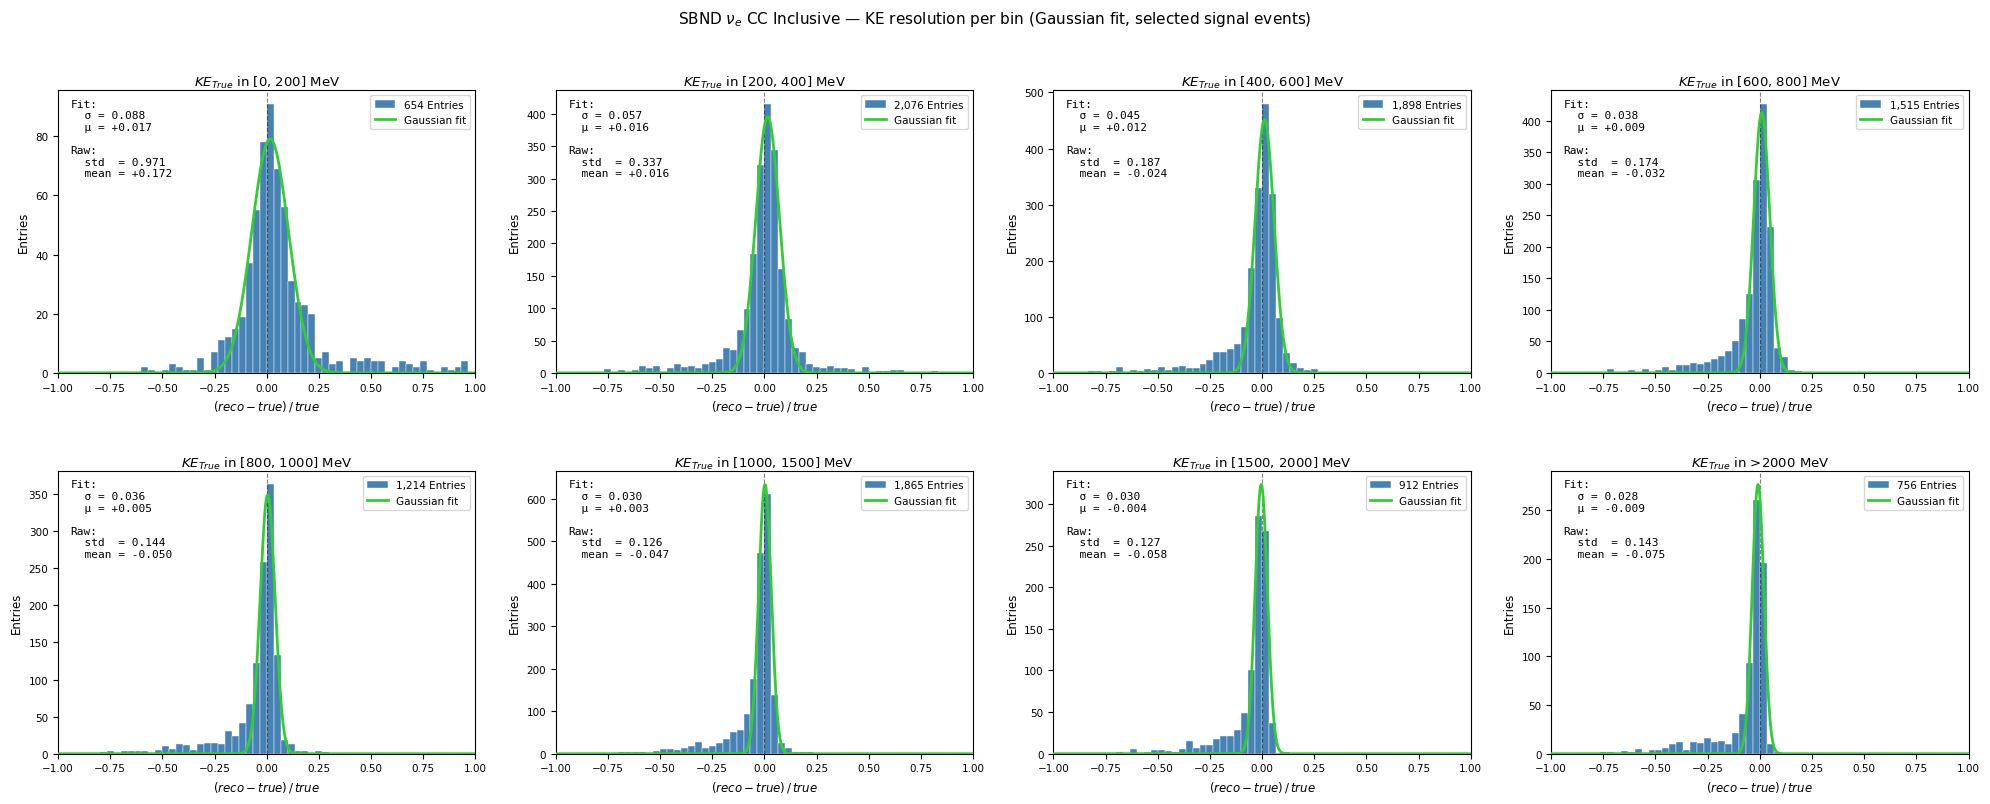

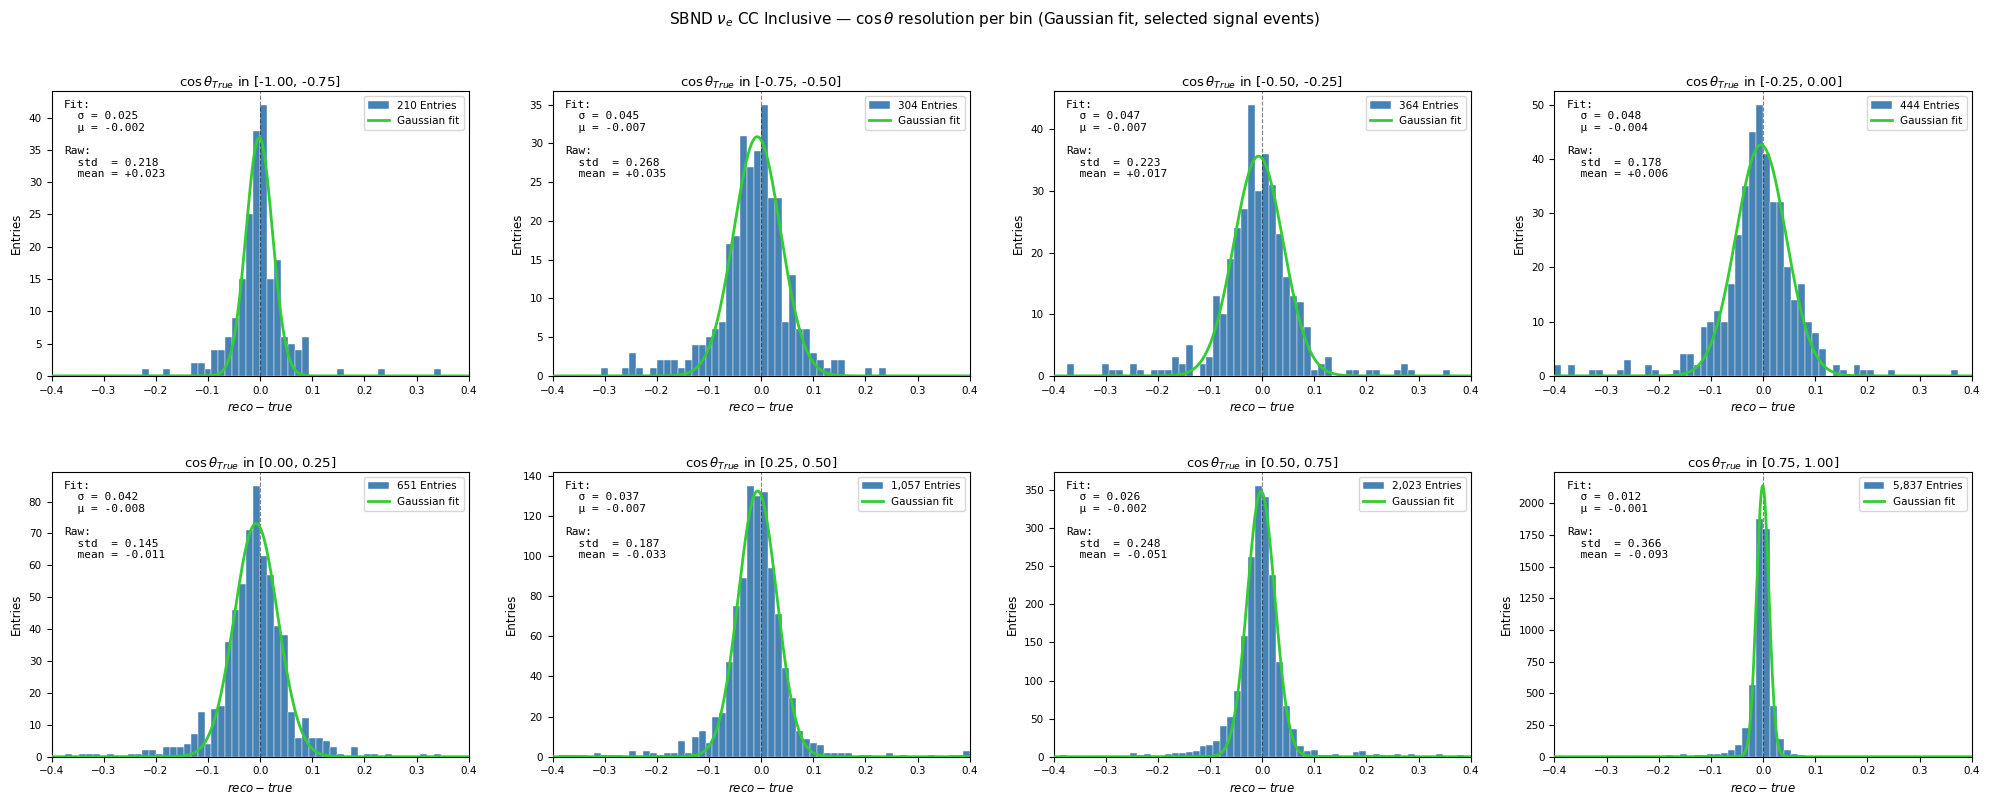

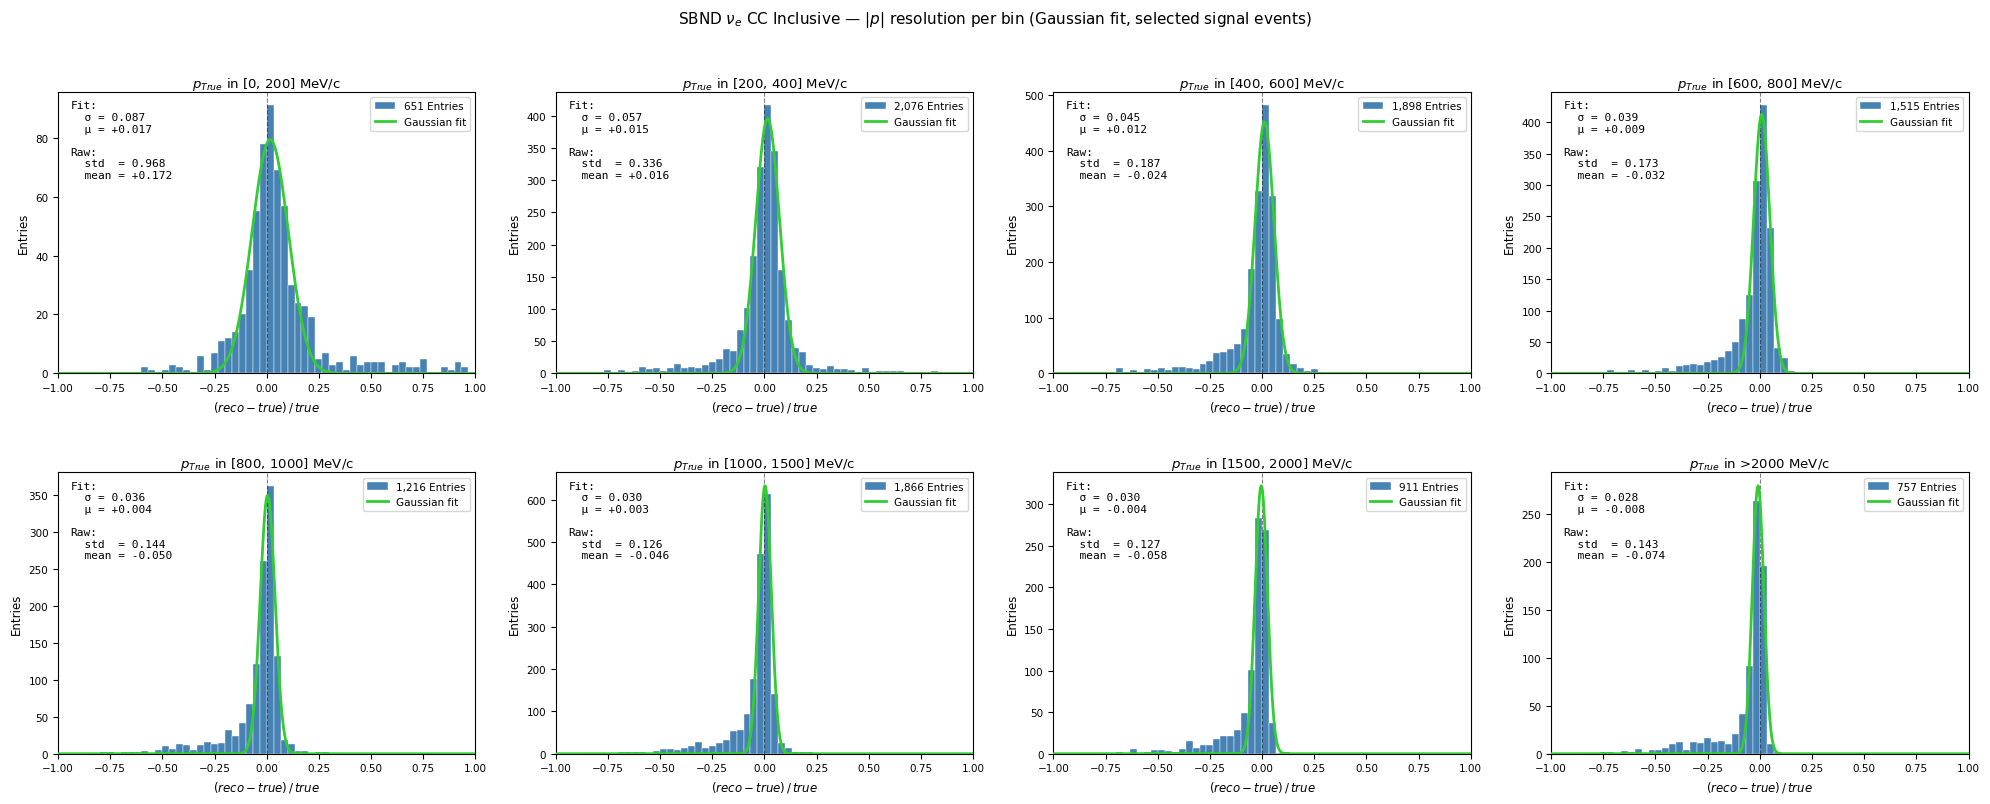

In [9]:
for v in _vars:
    fig, _ = plot_per_bin_panels(
        v['true'], v['reco'],
        bins          = v['bins'],
        bin_labels    = v['labels'],
        normalize     = v['normalize'],
        suptitle      = (fr"{TITLE} — {v['name']} resolution per bin"
                         fr" (Gaussian fit, selected signal events)"),
        bin_var_label = v['var_label'],
        unit          = v['unit'],
        res_range     = v['res_range'],
        n_cols        = 4,
        fit_type      = 'gauss',
    )
    plt.show()
    nh.save_plot(
        f"resolution_{v['tag']}_perbin_gauss",
        fig=fig,
        folder_name=PLOT_DIR
    )